# 06 · Preliminary comparison (common protocol)
Same split, same preprocessing per model family, same output layer/loss, same training budget,
same metrics. **All numbers are on the validation split** — the official test set is held out
until the final, tuned models are evaluated.

In [1]:
import os, sys
os.environ.setdefault("KERAS_BACKEND", "torch")   # Keras 3 backend used for our runs (CPU); "tensorflow" also works
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))        # make the project's src/ package importable

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from src import config, data_pipeline as dp, models, features, training

keras.utils.set_random_seed(config.SEED)
print("Keras", keras.__version__, "| backend:", keras.backend.backend())

Keras 3.15.1 | backend: torch


In [2]:
names = {"mlp_baseline": "MLP baseline", "vgg16": "VGG16", "resnet50": "ResNet50",
         "hybrid_vgg16_resnet50": "Hybrid VGG16-ResNet50"}
rows = []
for key, label in names.items():
    r = json.loads((config.METRIC_DIR / f"{key}.json").read_text())
    m = r["val_metrics"]
    tn, fp = m["confusion_matrix"][0]; fn, tp = m["confusion_matrix"][1]
    rows.append({"Model": label, "Accuracy": m["accuracy"], "Precision": m["precision"],
                 "Recall (sensitivity)": m["recall"], "Specificity": m["specificity"],
                 "F1": m["f1"], "Macro-F1": m["macro_f1"], "ROC-AUC": m["roc_auc"],
                 "FN (missed tumors)": fn, "FP": fp,
                 "Trainable params": r["trainable_params"], "Best epoch": r["best_epoch"]})
table = pd.DataFrame(rows).set_index("Model")
table.to_csv(config.METRIC_DIR / "comparison_val.csv")
table.round(4)

,Accuracy,Precision,Recall (sensitivity),Specificity,F1,Macro-F1,ROC-AUC,FN (missed tumors),FP,Trainable params,Best epoch
Model,,,,,,,,,,,
MLP baseline,0.9715,0.9784,0.9843,0.9297,0.9814,0.9601,0.9870,13,18,2163586,29
VGG16,0.9871,0.9916,0.9916,0.9727,0.9916,0.9821,0.9974,7,7,131842,14
ResNet50,0.9871,0.9880,0.9952,0.9609,0.9916,0.9820,0.9986,4,10,525058,5
Hybrid VGG16-ResNet50,0.9871,0.9892,0.9940,0.9648,0.9916,0.9820,0.9991,5,9,656130,9


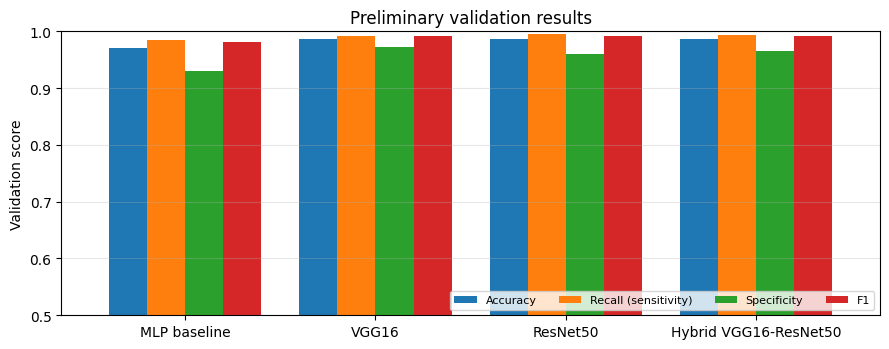

In [3]:
cols = ["Accuracy", "Recall (sensitivity)", "Specificity", "F1"]
ax = table[cols].plot.bar(figsize=(9, 3.6), rot=0, ylim=(0.5, 1.0), width=0.8)
ax.set_ylabel("Validation score"); ax.set_xlabel(""); ax.grid(axis="y", alpha=0.3)
ax.legend(ncol=4, fontsize=8, loc="lower right"); ax.set_title("Preliminary validation results")
plt.tight_layout(); plt.savefig(config.FIG_DIR / "comparison_val.png", dpi=150); plt.show()

## Sanity check: how far does the original image size alone get?
The no-tumor images come from a different source (Br35H) than the tumor images (mostly figshare,
512 × 512). The models only ever see resized images, but resizing images of different origin and
shape can leave cues (stretching, borders, contrast) that have nothing to do with a tumor.
A one-line rule that never looks at the pixels measures how strong that shortcut is.

In [4]:
from sklearn.metrics import accuracy_score, recall_score, f1_score
manifest = pd.read_csv(config.SPLIT_MANIFEST)
manifest["is_512x512"] = (manifest.width == 512) & (manifest.height == 512)
print("share of images that are exactly 512x512, per class:")
print(manifest.groupby("label")["is_512x512"].mean().round(3).to_string())
print()

val = manifest[manifest.split == "val"]
y_true = (val.label == "tumor").astype(int).to_numpy()
y_rule = val["is_512x512"].astype(int).to_numpy()          # rule: 512x512 -> tumor, else no tumor
rule = {"Accuracy": accuracy_score(y_true, y_rule), "Recall (sensitivity)": recall_score(y_true, y_rule),
        "Specificity": recall_score(1 - y_true, 1 - y_rule), "F1": f1_score(y_true, y_rule)}
rule = pd.Series(rule, name="Image-size rule (no model)").round(4)
rule.to_frame().T.to_csv(config.METRIC_DIR / "size_rule_val.csv")
rule.to_frame().T

share of images that are exactly 512x512, per class:
label
no_tumor    0.010
tumor       0.931



,Accuracy,Recall (sensitivity),Specificity,F1
Image-size rule (no model),0.9715,0.9663,0.9883,0.981
